In [1]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Retraining classifier layer with and without random re-init

In [2]:
sparsity_levels = [0.1, 0.3, 0.5, 0.7, 0.9, 1]

def read_retrained_accs(prune_method='random', reinit=False, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']

    assert model_name in ['vgg']

    metric = "ftval_acc"
    results_file = f'./results/{model_name}_{metric}_{prune_method}{"_reinit" if reinit else ""}.csv'

    df = pd.read_csv(results_file)
    res = df.to_numpy().T.astype(float)
    
    
    return res

def read_untrained_accs(prune_method='random', model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']

    assert model_name in ['vgg']

    metric = "val_acc"
    results_file = f'../1_representation_space/results/{model_name}_{metric}_{prune_method}_all.csv'

    df = pd.read_csv(results_file)
    res = df.to_numpy().T.astype(float)
    
    res = res[[0,2,4,6,8,9],:]
    
    return res

## Plot results

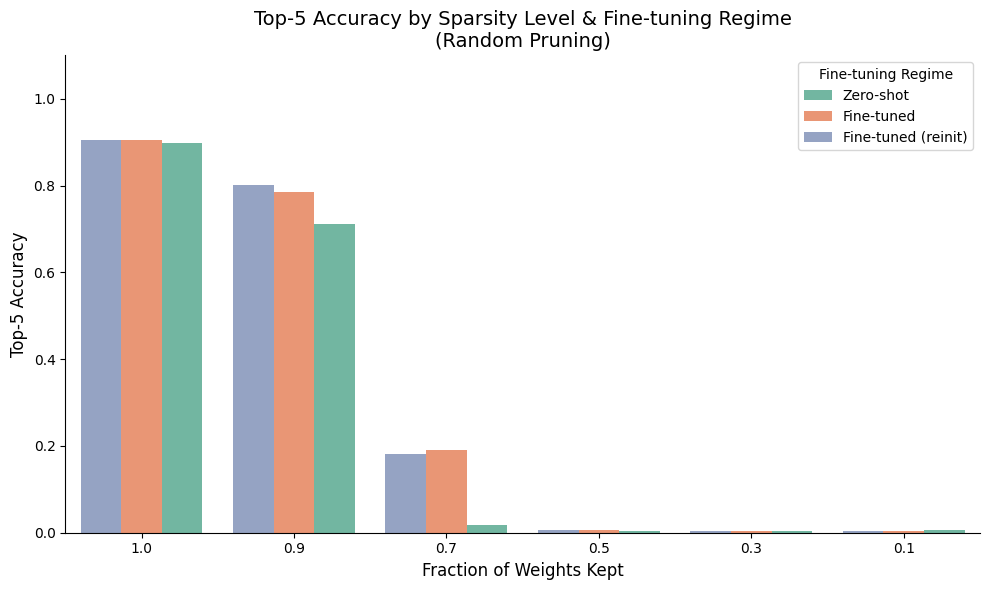

In [19]:
random_pruning_zeroshot_accs = read_untrained_accs(prune_method="random")
random_pruning_ft_accs = read_retrained_accs(prune_method="random", reinit=False)
random_pruning_reinitft_accs = read_retrained_accs(prune_method="random", reinit=True)

df = pd.DataFrame({
    "Sparsity": sparsity_levels * 3,
    "Top-5 Accuracy": np.concatenate([
        random_pruning_zeroshot_accs[:, 1],
        random_pruning_ft_accs[:, 1],
        random_pruning_reinitft_accs[:, 1],
    ]),
    "Regime": (
        ["Zero-shot"] * len(sparsity_levels) +
        ["Fine-tuned"] * len(sparsity_levels) +
        ["Fine-tuned (reinit)"] * len(sparsity_levels)
    )
})


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Sparsity",
    y="Top-5 Accuracy",
    hue="Regime",
    palette="Set2",
    ax=ax
)

ax.set_title("Top-5 Accuracy by Sparsity Level & Fine-tuning Regime\n(Random Pruning)", fontsize=14)
ax.set_xlabel("Fraction of Weights Kept", fontsize=12)
ax.set_ylabel("Top-5 Accuracy", fontsize=12)
ax.legend(title="Fine-tuning Regime", loc="upper right")
ax.set_ylim(0, 1.1)
ax.invert_xaxis()

sns.despine()
plt.tight_layout()
plt.show()


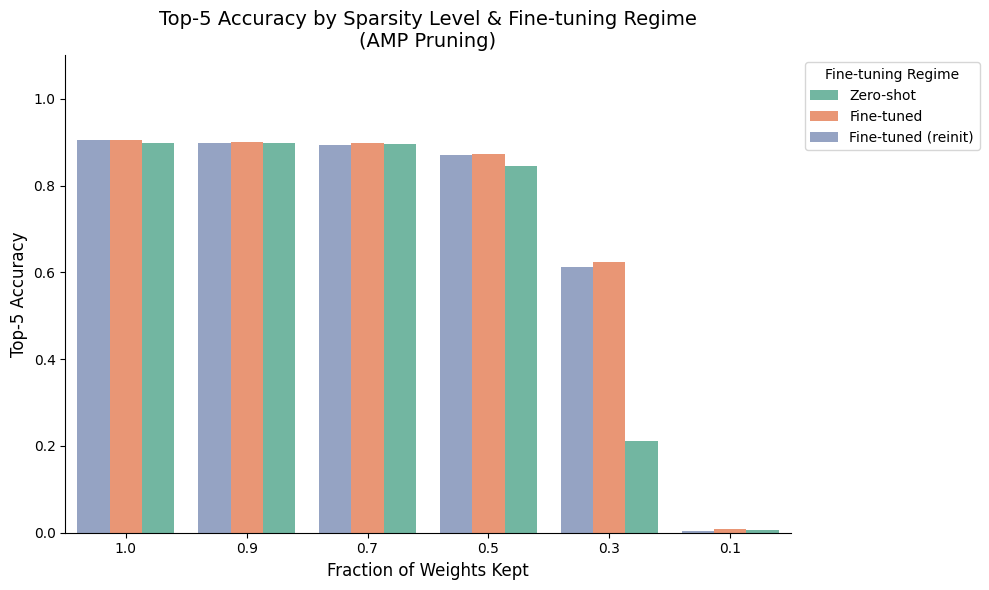

In [16]:
amp_pruning_zeroshot_accs = read_untrained_accs(prune_method="amp")
amp_pruning_ft_accs = read_retrained_accs(prune_method="amp", reinit=False)
amp_pruning_reinitft_accs = read_retrained_accs(prune_method="amp", reinit=True)

df = pd.DataFrame({
    "Sparsity": sparsity_levels * 3,
    "Top-5 Accuracy": np.concatenate([
        amp_pruning_zeroshot_accs[:, 1],
        amp_pruning_ft_accs[:, 1],
        amp_pruning_reinitft_accs[:, 1],
    ]),
    "Regime": (
        ["Zero-shot"] * len(sparsity_levels) +
        ["Fine-tuned"] * len(sparsity_levels) +
        ["Fine-tuned (reinit)"] * len(sparsity_levels)
    )
})


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Sparsity",
    y="Top-5 Accuracy",
    hue="Regime",
    palette="Set2",
    ax=ax
)

ax.set_title("Top-5 Accuracy by Sparsity Level & Fine-tuning Regime\n(AMP Pruning)", fontsize=14)
ax.set_xlabel("Fraction of Weights Kept", fontsize=12)
ax.set_ylabel("Top-5 Accuracy", fontsize=12)
ax.legend(title="Fine-tuning Regime", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 1.1)
ax.invert_xaxis()
sns.despine()
plt.tight_layout()
plt.show()


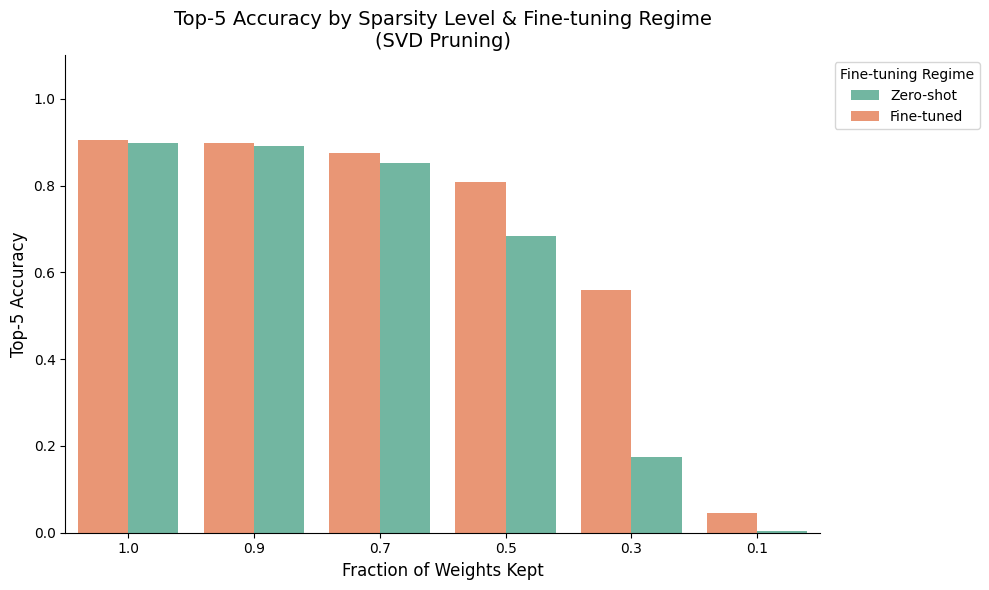

In [17]:
svd_pruning_zeroshot_accs = read_untrained_accs(prune_method="svd")
svd_pruning_ft_accs = read_retrained_accs(prune_method="svd", reinit=False)
# svd_pruning_reinitft_accs = read_retrained_accs(prune_method="svd", reinit=True)

df = pd.DataFrame({
    "Sparsity": sparsity_levels * 2,
    "Top-5 Accuracy": np.concatenate([
        svd_pruning_zeroshot_accs[:, 1],
        svd_pruning_ft_accs[:, 1],
        # svd_pruning_reinitft_accs[:, 1],
    ]),
    "Regime": (
        ["Zero-shot"] * len(sparsity_levels) +
        ["Fine-tuned"] * len(sparsity_levels) 
        # ["Fine-tuned (reinit)"] * len(sparsity_levels)
    )
})


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Sparsity",
    y="Top-5 Accuracy",
    hue="Regime",
    palette="Set2",
    ax=ax
)

ax.set_title("Top-5 Accuracy by Sparsity Level & Fine-tuning Regime\n(SVD Pruning)", fontsize=14)
ax.set_xlabel("Fraction of Weights Kept", fontsize=12)
ax.set_ylabel("Top-5 Accuracy", fontsize=12)
ax.legend(title="Fine-tuning Regime", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 1.1)
ax.invert_xaxis()

sns.despine()
plt.tight_layout()
plt.show()
